# Lab 2 — Anomaly Detection

## Project Scenario: Microsoft 365 Login Anomaly Detection

This lab focuses on detecting suspicious Microsoft 365 login events using anomaly detection.  
The dataset simulates normal and abnormal login behavior in a cloud-based organization.

Normal activity includes employee logins during business hours, from common locations, using common devices, with a low number of failed login attempts and normal traffic volume.

Anomalous activity represents suspicious behavior that may indicate account compromise, brute force attempts, or misuse of valid cloud accounts.  
Examples include logins at unusual hours, logins from uncommon cities, many failed attempts, short sessions, and unusually high data transfer.

This scenario is connected to the Jingle Thief CTI report from Lab 1, where attackers used phishing and smishing to steal Microsoft 365 credentials and access legitimate cloud accounts.

## MITRE ATT&CK Techniques

- T1078.004 — Valid Accounts: Cloud Accounts
- T1110 — Brute Force
- T1526 — Cloud Service Discovery

## MITRE ATT&CK Mapping

The simulated anomalies can be mapped to the following MITRE ATT&CK techniques:

- **T1078.004 — Valid Accounts: Cloud Accounts**: suspicious successful logins using legitimate Microsoft 365 accounts.
- **T1110 — Brute Force**: login events with many failed attempts before success.
- **T1526 — Cloud Service Discovery**: suspicious access to cloud services such as SharePoint, OneDrive, Exchange, and Entra ID.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)

## Dataset Generation

We generate a synthetic Microsoft 365 login dataset.

The dataset contains:
- Normal login events
- Anomalous login events

Normal events represent common employee behavior.  
Anomalous events represent suspicious activity such as unusual login hours, uncommon locations, many failed login attempts, short sessions, and high data transfer.

In [2]:
n_normal = 950
n_anomaly = 50

users = [f"user_{i}" for i in range(1, 51)]

normal_cities = ["Tel Aviv", "Jerusalem", "Haifa", "Beer Sheva", "Ramat Gan"]
anomaly_cities = ["Moscow", "Beijing", "Tehran", "Unknown", "Lagos"]

devices = ["Windows Laptop", "MacBook", "iPhone", "Android"]
services = ["Exchange", "SharePoint", "OneDrive", "Teams", "Entra ID"]

# Normal login events
normal_data = pd.DataFrame({
    "timestamp": pd.date_range(start="2026-01-01 08:00:00", periods=n_normal, freq="15min"),
    "user": np.random.choice(users, n_normal),
    "hour": np.random.choice(range(8, 19), n_normal),
    "city": np.random.choice(normal_cities, n_normal),
    "device_type": np.random.choice(devices, n_normal),
    "cloud_service": np.random.choice(services, n_normal),
    "failed_attempts": np.random.choice([0, 1, 2], n_normal, p=[0.75, 0.20, 0.05]),
    "session_duration_min": np.random.normal(loc=45, scale=15, size=n_normal).clip(5, 120),
    "bytes_sent": np.random.normal(loc=1500, scale=500, size=n_normal).clip(100, 4000),
    "label": "normal"
})

# Anomalous login events
anomaly_data = pd.DataFrame({
    "timestamp": pd.date_range(start="2026-01-15 00:00:00", periods=n_anomaly, freq="37min"),
    "user": np.random.choice(users, n_anomaly),
    "hour": np.random.choice([0, 1, 2, 3, 4, 23], n_anomaly),
    "city": np.random.choice(anomaly_cities, n_anomaly),
    "device_type": np.random.choice(devices, n_anomaly),
    "cloud_service": np.random.choice(["SharePoint", "OneDrive", "Exchange", "Entra ID"], n_anomaly),
    "failed_attempts": np.random.randint(6, 20, n_anomaly),
    "session_duration_min": np.random.normal(loc=5, scale=3, size=n_anomaly).clip(1, 20),
    "bytes_sent": np.random.normal(loc=15000, scale=5000, size=n_anomaly).clip(5000, 40000),
    "label": "anomaly"
})

df = pd.concat([normal_data, anomaly_data], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,timestamp,user,hour,city,device_type,cloud_service,failed_attempts,session_duration_min,bytes_sent,label
0,2026-01-06 18:15:00,user_24,17,Jerusalem,Android,OneDrive,1,9.825444,1035.183024,normal
1,2026-01-09 00:15:00,user_8,8,Haifa,MacBook,Teams,0,45.551373,1502.858043,normal
2,2026-01-09 01:00:00,user_26,10,Ramat Gan,iPhone,OneDrive,0,48.379978,1714.558465,normal
3,2026-01-08 05:00:00,user_38,12,Jerusalem,Android,Teams,0,36.790745,1788.790090,normal
4,2026-01-05 14:45:00,user_36,13,Tel Aviv,Android,Exchange,0,59.006104,1895.435056,normal


In [3]:
print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["label"].value_counts())

df.head(10)

Dataset shape: (1000, 10)

Label distribution:
label
normal     950
anomaly     50
Name: count, dtype: int64


,timestamp,user,hour,city,device_type,cloud_service,failed_attempts,session_duration_min,bytes_sent,label
0,2026-01-06 18:15:00,user_24,17,Jerusalem,Android,OneDrive,1,9.825444,1035.183024,normal
1,2026-01-09 00:15:00,user_8,8,Haifa,MacBook,Teams,0,45.551373,1502.858043,normal
2,2026-01-09 01:00:00,user_26,10,Ramat Gan,iPhone,OneDrive,0,48.379978,1714.558465,normal
3,2026-01-08 05:00:00,user_38,12,Jerusalem,Android,Teams,0,36.790745,1788.790090,normal
4,2026-01-05 14:45:00,user_36,13,Tel Aviv,Android,Exchange,0,59.006104,1895.435056,normal
5,2026-01-08 09:30:00,user_27,16,Haifa,MacBook,Teams,0,22.276136,1523.810510,normal
6,2026-01-07 20:30:00,user_23,8,Tel Aviv,Windows Laptop,Exchange,0,41.489463,1500.208982,normal
7,2026-01-06 16:15:00,user_10,16,Haifa,Windows Laptop,Exchange,1,55.375816,1369.749705,normal
8,2026-01-10 06:45:00,user_30,15,Tel Aviv,iPhone,Exchange,0,30.544649,1856.015860,normal
9,2026-01-02 18:00:00,user_47,18,Beer Sheva,MacBook,OneDrive,0,59.552952,2101.768291,normal


## Exploratory Data Analysis (EDA)

In this section, we inspect the dataset to understand the difference between normal and anomalous login events.

We analyze:
- Label distribution
- Login hours
- Failed login attempts
- Session duration
- Data transfer volume
- Login locations

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             1000 non-null   datetime64[ns]
 1   user                  1000 non-null   object        
 2   hour                  1000 non-null   int32         
 3   city                  1000 non-null   object        
 4   device_type           1000 non-null   object        
 5   cloud_service         1000 non-null   object        
 6   failed_attempts       1000 non-null   int32         
 7   session_duration_min  1000 non-null   float64       
 8   bytes_sent            1000 non-null   float64       
 9   label                 1000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int32(2), object(5)
memory usage: 50.9+ KB


In [5]:
df["label"].value_counts()

label
normal     950
anomaly     50
Name: count, dtype: int64

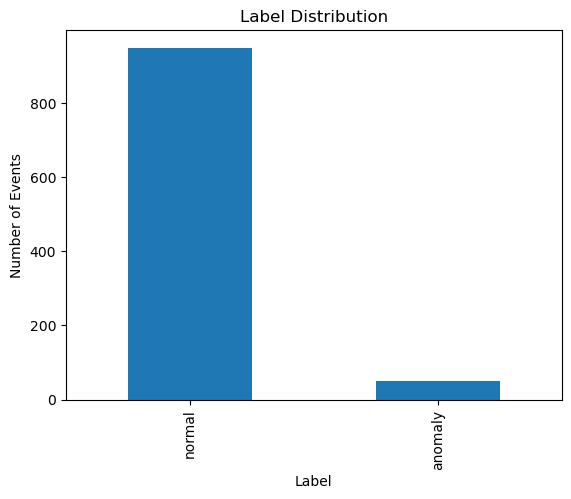

In [6]:
df["label"].value_counts().plot(kind="bar")

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Events")
plt.show()

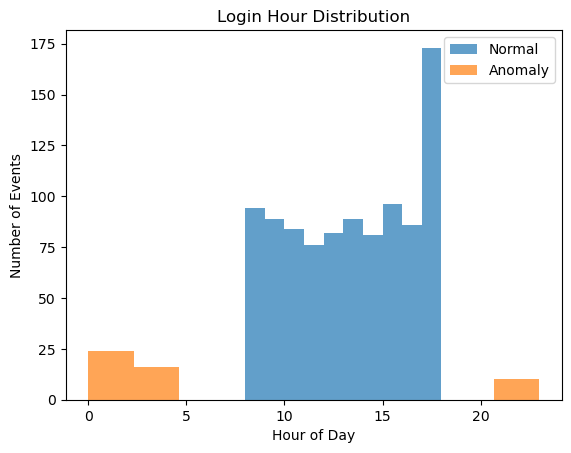

In [7]:
plt.hist(df[df["label"] == "normal"]["hour"], alpha=0.7, label="Normal")
plt.hist(df[df["label"] == "anomaly"]["hour"], alpha=0.7, label="Anomaly")

plt.title("Login Hour Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Events")
plt.legend()
plt.show()

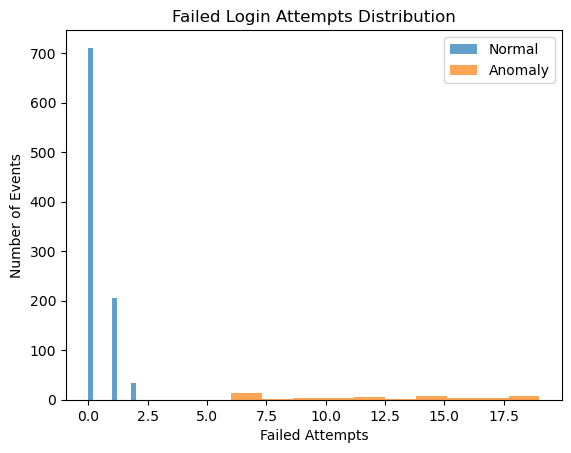

In [8]:
plt.hist(df[df["label"] == "normal"]["failed_attempts"], alpha=0.7, label="Normal")
plt.hist(df[df["label"] == "anomaly"]["failed_attempts"], alpha=0.7, label="Anomaly")

plt.title("Failed Login Attempts Distribution")
plt.xlabel("Failed Attempts")
plt.ylabel("Number of Events")
plt.legend()
plt.show()

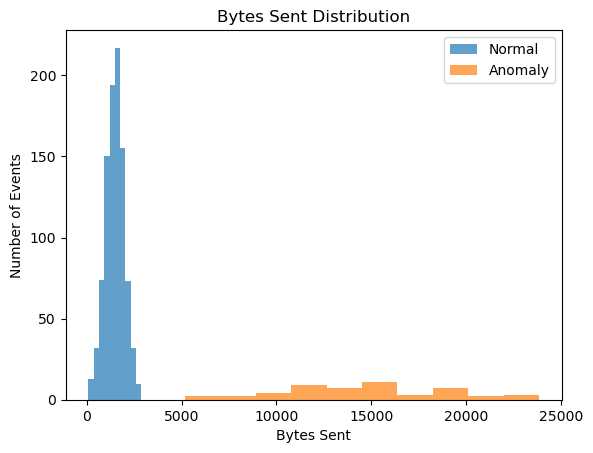

In [9]:
plt.hist(df[df["label"] == "normal"]["bytes_sent"], alpha=0.7, label="Normal")
plt.hist(df[df["label"] == "anomaly"]["bytes_sent"], alpha=0.7, label="Anomaly")

plt.title("Bytes Sent Distribution")
plt.xlabel("Bytes Sent")
plt.ylabel("Number of Events")
plt.legend()
plt.show()

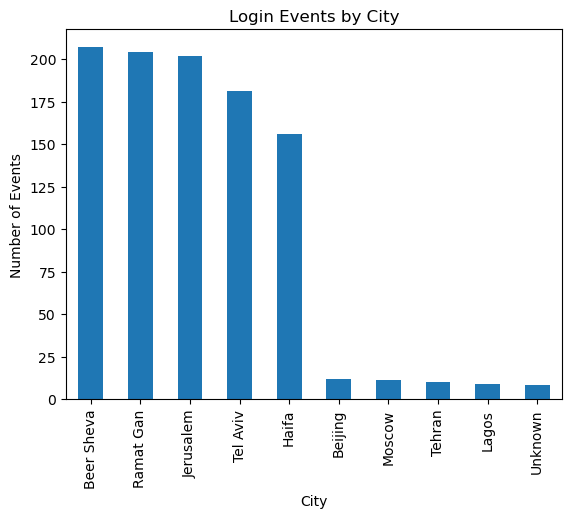

In [10]:
df["city"].value_counts().plot(kind="bar")

plt.title("Login Events by City")
plt.xlabel("City")
plt.ylabel("Number of Events")
plt.show()

## EDA Summary

The dataset contains mostly normal events and a small percentage of anomalous events.

Normal login events usually occur during business hours, from common locations, with a low number of failed attempts and normal data transfer volume.

Anomalous login events are different from normal behavior. They usually occur at unusual hours, from uncommon cities, with many failed attempts, short session durations, and unusually high bytes sent.

These differences suggest that anomaly detection can be useful for identifying suspicious Microsoft 365 login activity.

## Preprocessing

Before training the Isolation Forest model, we need to prepare the dataset.

The model can only work with numerical values, so categorical columns such as `user`, `city`, `device_type`, and `cloud_service` must be encoded.

We also scale the numerical columns so that features with larger values, such as `bytes_sent`, do not dominate the model.

In [11]:
# Separate features from labels
X = df.drop(columns=["timestamp", "label"])
y = df["label"]

# Define feature types
categorical_features = ["user", "city", "device_type", "cloud_service"]
numeric_features = ["hour", "failed_attempts", "session_duration_min", "bytes_sent"]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", StandardScaler(), numeric_features)
    ]
)

X_preprocessed = preprocessor.fit_transform(X)

print("Original feature shape:", X.shape)
print("Preprocessed feature shape:", X_preprocessed.shape)

Original feature shape: (1000, 8)
Preprocessed feature shape: (1000, 73)


## Isolation Forest Model

Isolation Forest is an unsupervised anomaly detection algorithm.  
It works by isolating unusual data points that are easier to separate from the rest of the dataset.

In this lab, we use Isolation Forest to detect suspicious Microsoft 365 login events.  
The contamination value is set to `0.05` because the dataset contains 5% anomalous events.

In [12]:
# Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

iso_forest.fit(X_preprocessed)

# Predict anomalies
# Isolation Forest returns:
#  1  = normal
# -1  = anomaly
predictions = iso_forest.predict(X_preprocessed)

# Convert predictions to readable labels
df["predicted_label"] = np.where(predictions == -1, "anomaly", "normal")

# Add anomaly score
# Lower scores usually indicate more anomalous behavior
df["anomaly_score"] = iso_forest.decision_function(X_preprocessed)

df[["timestamp", "user", "city", "hour", "failed_attempts", "bytes_sent", "label", "predicted_label", "anomaly_score"]].head(10)

,timestamp,user,city,hour,failed_attempts,bytes_sent,label,predicted_label,anomaly_score
0,2026-01-06 18:15:00,user_24,Jerusalem,17,1,1035.183024,normal,normal,0.024937
1,2026-01-09 00:15:00,user_8,Haifa,8,0,1502.858043,normal,normal,0.028923
2,2026-01-09 01:00:00,user_26,Ramat Gan,10,0,1714.558465,normal,normal,0.032850
3,2026-01-08 05:00:00,user_38,Jerusalem,12,0,1788.790090,normal,normal,0.018644
4,2026-01-05 14:45:00,user_36,Tel Aviv,13,0,1895.435056,normal,normal,0.029167
5,2026-01-08 09:30:00,user_27,Haifa,16,0,1523.810510,normal,normal,0.022882
6,2026-01-07 20:30:00,user_23,Tel Aviv,8,0,1500.208982,normal,normal,0.021616
7,2026-01-06 16:15:00,user_10,Haifa,16,1,1369.749705,normal,normal,0.029140
8,2026-01-10 06:45:00,user_30,Tel Aviv,15,0,1856.015860,normal,normal,0.001193
9,2026-01-02 18:00:00,user_47,Beer Sheva,18,0,2101.768291,normal,normal,0.012806


In [13]:
predicted_anomalies = df[df["predicted_label"] == "anomaly"]

print("Number of predicted anomalies:", len(predicted_anomalies))

predicted_anomalies[
    ["timestamp", "user", "city", "hour", "cloud_service",
     "failed_attempts", "session_duration_min", "bytes_sent",
     "label", "predicted_label", "anomaly_score"]
].head(20)

Number of predicted anomalies: 50


,timestamp,user,city,hour,cloud_service,failed_attempts,session_duration_min,bytes_sent,label,predicted_label,anomaly_score
13,2026-01-15 14:11:00,user_2,Moscow,23,SharePoint,15,5.448026,12294.965671,anomaly,anomaly,-0.022683
27,2026-01-15 22:12:00,user_38,Beijing,23,SharePoint,6,1.000000,11856.728475,anomaly,anomaly,-0.048139
43,2026-01-15 14:48:00,user_38,Moscow,0,OneDrive,11,1.000000,18778.329194,anomaly,anomaly,-0.057488
86,2026-01-16 05:36:00,user_20,Beijing,1,SharePoint,15,3.289058,13366.633762,anomaly,anomaly,-0.060371
107,2026-01-15 05:33:00,user_39,Beijing,0,Exchange,9,3.328608,6130.151919,anomaly,anomaly,-0.024426
133,2026-01-16 03:45:00,user_24,Lagos,0,Entra ID,16,6.933786,14893.776104,anomaly,anomaly,-0.042294
152,2026-01-15 16:39:00,user_43,Tehran,4,OneDrive,18,7.199163,23840.846465,anomaly,anomaly,-0.033541
161,2026-01-09 07:45:00,user_30,Beer Sheva,9,Exchange,1,20.943719,2170.874742,normal,anomaly,-0.004604
173,2026-01-16 00:03:00,user_50,Tehran,2,OneDrive,19,8.355650,13982.694295,anomaly,anomaly,-0.049063
222,2026-01-15 15:25:00,user_15,Unknown,23,SharePoint,9,7.409464,13890.558644,anomaly,anomaly,-0.019928


## Model Evaluation

Because this dataset is synthetic, we have the real labels for each event.  
This allows us to compare the model predictions with the actual labels.

The goal is to check whether the Isolation Forest model correctly identifies suspicious login events as anomalies.

In [14]:


print("\nClassification Report:")
print(classification_report(y, df["predicted_label"]))


Classification Report:
              precision    recall  f1-score   support

     anomaly       0.94      0.94      0.94        50
      normal       1.00      1.00      1.00       950

    accuracy                           0.99      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.99      0.99      0.99      1000



## Interpretation of Evaluation Results

The model achieved high evaluation scores. However, this does not necessarily mean that the model would perform equally well in a real environment.

The dataset is synthetic, and the anomalous events were intentionally generated to be different from normal login behavior. For example, anomalous events often include unusual login hours, uncommon locations, many failed attempts, and higher data transfer volume.

Therefore, the high performance should be interpreted carefully. The result shows that Isolation Forest can detect clearly abnormal behavior, but a real-world dataset would likely contain more overlap between normal and malicious activity, making the task more difficult.

In [15]:
cm = confusion_matrix(y, df["predicted_label"], labels=["normal", "anomaly"])

cm_df = pd.DataFrame(
    cm,
    index=["Actual Normal", "Actual Anomaly"],
    columns=["Predicted Normal", "Predicted Anomaly"]
)

cm_df

,Predicted Normal,Predicted Anomaly
Actual Normal,947,3
Actual Anomaly,3,47


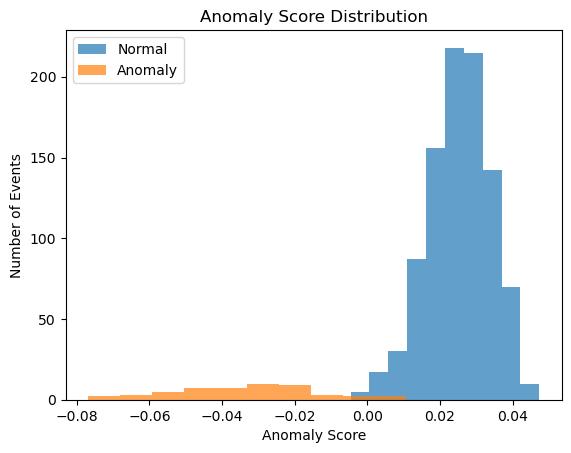

In [16]:
plt.hist(df[df["label"] == "normal"]["anomaly_score"], alpha=0.7, label="Normal")
plt.hist(df[df["label"] == "anomaly"]["anomaly_score"], alpha=0.7, label="Anomaly")

plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Events")
plt.legend()
plt.show()

## Evaluation Summary

The Isolation Forest model was trained to detect rare and unusual login events.

The model compares each login event to the overall behavior pattern in the dataset.  
Events with unusual combinations of features, such as uncommon locations, unusual login hours, many failed attempts, and high data transfer, are more likely to be classified as anomalies.

Because the dataset is synthetic and the anomalous events were intentionally designed to be different from normal events, the model is expected to perform well.  
In a real-world environment, the results may be less perfect because normal and malicious behavior can overlap.

## 2D Visualization with PCA

To better understand the model results, we reduce the preprocessed feature space into two dimensions using PCA.

PCA allows us to visualize high-dimensional login events on a 2D scatter plot.  
This helps us see whether predicted anomalies appear separated from normal events or located near the edges of the main cluster.

In [17]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(
    X_preprocessed.toarray() if hasattr(X_preprocessed, "toarray") else X_preprocessed
)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

df[["PC1", "PC2", "label", "predicted_label"]].head()

Explained variance ratio: [0.33193487 0.11532548]


,PC1,PC2,label,predicted_label
0,0.337108,1.739666,normal,normal
1,-0.010396,-1.195246,normal,normal
2,-0.194363,-0.774019,normal,normal
3,-0.055316,-0.030310,normal,normal
4,-0.673887,-0.309693,normal,normal


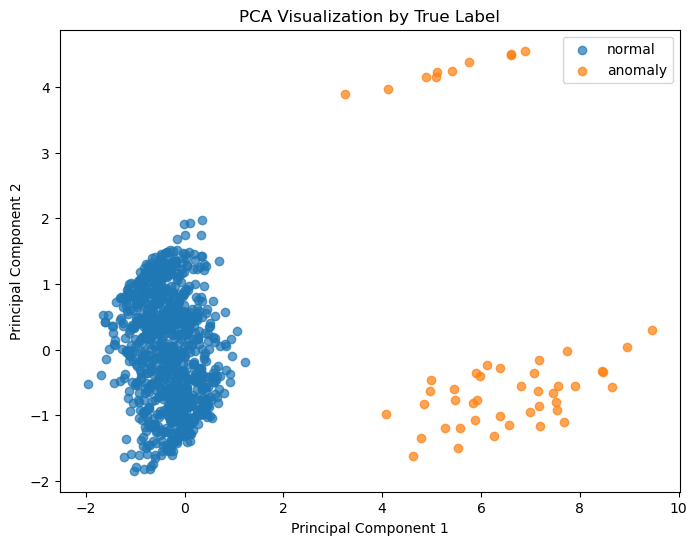

In [18]:
plt.figure(figsize=(8, 6))

for label in df["label"].unique():
    subset = df[df["label"] == label]
    plt.scatter(subset["PC1"], subset["PC2"], label=label, alpha=0.7)

plt.title("PCA Visualization by True Label")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

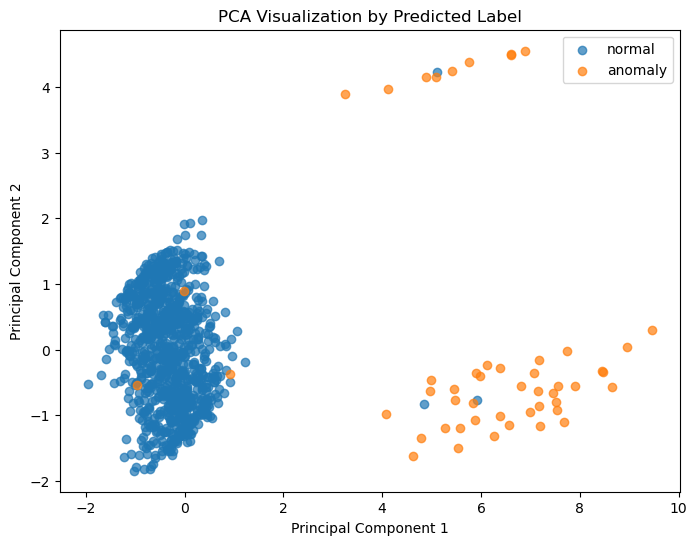

In [19]:
plt.figure(figsize=(8, 6))

for label in df["predicted_label"].unique():
    subset = df[df["predicted_label"] == label]
    plt.scatter(subset["PC1"], subset["PC2"], label=label, alpha=0.7)

plt.title("PCA Visualization by Predicted Label")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

## PCA Visualization Summary

The PCA plots reduce the dataset into two dimensions so that the login events can be visualized.

The true-label plot shows how the original normal and anomalous events are distributed.  
The predicted-label plot shows which events the Isolation Forest model classified as anomalies.

If the anomalous events appear near the edges of the main cluster or separated from most normal events, it supports the idea that the model is detecting unusual login behavior.

In [20]:
strongest_anomalies = df.sort_values("anomaly_score").head(10)

strongest_anomalies[
    [
        "timestamp",
        "user",
        "city",
        "hour",
        "cloud_service",
        "failed_attempts",
        "session_duration_min",
        "bytes_sent",
        "label",
        "predicted_label",
        "anomaly_score"
    ]
]

,timestamp,user,city,hour,cloud_service,failed_attempts,session_duration_min,bytes_sent,label,predicted_label,anomaly_score
505,2026-01-15 06:10:00,user_7,Beijing,2,OneDrive,17,3.240755,11569.751215,anomaly,anomaly,-0.076809
618,2026-01-15 20:58:00,user_28,Beijing,1,Entra ID,16,2.445380,19880.203597,anomaly,anomaly,-0.073536
627,2026-01-15 12:57:00,user_41,Beijing,0,Exchange,12,5.485096,11833.843016,anomaly,anomaly,-0.061318
86,2026-01-16 05:36:00,user_20,Beijing,1,SharePoint,15,3.289058,13366.633762,anomaly,anomaly,-0.060371
463,2026-01-15 06:47:00,user_11,Tehran,1,Exchange,18,3.140684,11913.938767,anomaly,anomaly,-0.059746
646,2026-01-15 10:29:00,user_41,Moscow,3,Exchange,17,1.000000,20919.937216,anomaly,anomaly,-0.059144
43,2026-01-15 14:48:00,user_38,Moscow,0,OneDrive,11,1.000000,18778.329194,anomaly,anomaly,-0.057488
508,2026-01-15 03:42:00,user_12,Beijing,2,Exchange,12,12.715986,19819.534670,anomaly,anomaly,-0.052444
251,2026-01-16 01:17:00,user_15,Moscow,2,OneDrive,17,3.429272,18298.249990,anomaly,anomaly,-0.052169
720,2026-01-15 04:56:00,user_50,Beijing,1,OneDrive,6,6.826207,11143.998502,anomaly,anomaly,-0.051260


## Strongest Anomalies Summary

The table above shows the login events with the lowest anomaly scores.  
These events are considered the most suspicious by the Isolation Forest model.

Most of these events include one or more suspicious indicators, such as unusual login locations, unusual login hours, many failed login attempts, short session duration, or high data transfer.

This helps explain why the model classified these events as anomalies.

## Final Conclusion

In this lab, we created a synthetic Microsoft 365 login dataset and used Isolation Forest to detect suspicious login activity.

The detected anomalies were mainly related to unusual login hours, uncommon locations, many failed login attempts, short sessions, and higher data transfer volume.  
These behaviors can be connected to MITRE ATT&CK techniques such as **T1078.004 — Valid Accounts: Cloud Accounts**, **T1110 — Brute Force**, and **T1526 — Cloud Service Discovery**.

This lab is connected to Lab 1 because the Jingle Thief CTI report described attackers stealing Microsoft 365 credentials and abusing legitimate Microsoft 365 cloud accounts.  
Lab 2 turns this idea into a detection experiment by showing how suspicious account activity could be identified using anomaly detection.

The main limitation is that the dataset is synthetic.  
In a real enterprise environment, normal and malicious behavior may overlap, and the model would need to be tested on realistic logs, tuned carefully, and combined with additional security signals.